In [1]:
# %%
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================
import os, warnings, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import sys
import time

print("Torch:", torch.__version__, " | Numpy:", np.__version__, " | Python:", sys.version)

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

device = "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else \
         ("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

# ============================================================
# OPTIMIZED CONFIGURATION FOR 33 FLARES
# ============================================================
DATA_DIR = "preprocessed_data"
IMG_CHANNELS = 13
IMG_SIZE = 256  # ← UPGRADED from 128 to 256
EPOCHS = 100    # ← INCREASED from 80
BATCH_SIZE = 2  # ← INCREASED from 1 (with 33 flares we can use batch=2)
LR = 3e-4       # ← REDUCED learning rate for stability
WEIGHT_DECAY = 1e-4
SCHED_STEP, SCHED_GAMMA = 25, 0.5  # ← Adjusted for longer training
TARGET_SCALE = 1e-4
LOSS_WEIGHTS = torch.tensor([0.5, 0.3, 0.2], dtype=torch.float32)  # ← More balanced

print(f"""
OPTIMIZED CONFIGURATION FOR 33 FLARES:
- Image Size: {IMG_SIZE}×{IMG_SIZE}
- Epochs: {EPOCHS}
- Batch Size: {BATCH_SIZE}
- Learning Rate: {LR}
- Scheduler: StepLR (step={SCHED_STEP}, gamma={SCHED_GAMMA})
""")

Torch: 2.8.0  | Numpy: 2.2.6  | Python: 3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
✅ Device: mps

OPTIMIZED CONFIGURATION FOR 33 FLARES:
- Image Size: 256×256
- Epochs: 100
- Batch Size: 2
- Learning Rate: 0.0003
- Scheduler: StepLR (step=25, gamma=0.5)



In [2]:
# %%
# ============================================================
# CELL 2: Load Dataset
# ============================================================
# NOTE: You need to regenerate your preprocessed data at 256×256!
# If you still have 128×128 data, this will fail

try:
    X = np.load(os.path.join(DATA_DIR, "X_aiahmi_256.npy"))  # 256×256 version
    Y = np.load(os.path.join(DATA_DIR, "Y_aiahmi_256.npy"))
    print(f"✅ Loaded 256×256 dataset → X: {X.shape}, Y: {Y.shape}")
except FileNotFoundError:
    print("⚠️  256×256 data not found, loading 128×128...")
    X = np.load(os.path.join(DATA_DIR, "X_aiahmi.npy"))
    Y = np.load(os.path.join(DATA_DIR, "Y_aiahmi.npy"))
    print(f"⚠️  Using 128×128 dataset → X: {X.shape}, Y: {Y.shape}")
    print("   Consider regenerating at 256×256 for better performance!")

# Zero-mean target scaling
Y_scaled = (Y - Y.mean(axis=0)) / TARGET_SCALE
print(f"Target scaling: Mean={Y.mean(axis=0)}, Scale={TARGET_SCALE}")

# Load flare IDs
flare_ids = pd.read_csv("flare_euv_targets_3day.csv")["flare_id"].tolist()
assert len(flare_ids) == len(X), f"Mismatch: {len(X)} samples vs {len(flare_ids)} flare IDs"
print(f"✅ Loaded {len(flare_ids)} flares")

# Print dataset statistics
print(f"\nDataset Statistics:")
print(f"  Min/Max irradiance: {Y.min():.2e} / {Y.max():.2e}")
print(f"  Mean ± Std: {Y.mean():.2e} ± {Y.std():.2e}")

✅ Loaded 256×256 dataset → X: (33, 13, 256, 256), Y: (33, 3)
Target scaling: Mean=[8.8646077e-05 8.8066365e-05 8.8103399e-05], Scale=0.0001
✅ Loaded 33 flares

Dataset Statistics:
  Min/Max irradiance: 6.04e-05 / 1.21e-04
  Mean ± Std: 8.83e-05 ± 1.53e-05


In [3]:
# %%
# ============================================================
# CELL 3: Global Standardization + Dataset Class
# ============================================================
def compute_global_stats(X):
    """Compute per-channel mean and std across all samples"""
    C = X.shape[1]
    means = np.array([X[:, c].mean() for c in range(C)], dtype=np.float32)
    stds  = np.array([X[:, c].std() + 1e-6 for c in range(C)], dtype=np.float32)
    return means, stds

GLOBAL_MEAN, GLOBAL_STD = compute_global_stats(X)
print("✅ Global statistics computed")
print(f"   Channel means: {GLOBAL_MEAN[:3]}... (showing first 3)")
print(f"   Channel stds:  {GLOBAL_STD[:3]}... (showing first 3)")

class FlareDataset(Dataset):
    def __init__(self, X, Y, mean, std, augment=False):
        self.X = X.astype(np.float32)
        self.Y = Y.astype(np.float32)
        self.mean = mean.astype(np.float32)
        self.std = std.astype(np.float32)
        self.augment = augment
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = (self.X[idx] - self.mean[:, None, None]) / self.std[:, None, None]
        y = self.Y[idx]
        
        # Data augmentation for training (random flips)
        if self.augment and np.random.rand() > 0.5:
            x = np.flip(x, axis=1).copy()  # Horizontal flip
        if self.augment and np.random.rand() > 0.5:
            x = np.flip(x, axis=2).copy()  # Vertical flip
        
        return torch.tensor(x), torch.tensor(y)

print("✅ Dataset class ready (with augmentation support)")

✅ Global statistics computed
   Channel means: [0.41056433 0.49668843 0.7356721 ]... (showing first 3)
   Channel stds:  [0.18767157 0.23753043 0.21912515]... (showing first 3)
✅ Dataset class ready (with augmentation support)


In [4]:
# %%
# ============================================================
# CELL 4: VANILLA RESNET-34 BASELINE (No Attention)
# ============================================================
class VanillaResNet34(nn.Module):
    """
    Vanilla ResNet-34 baseline for EUV forecasting
    
    Architecture:
    - Standard ResNet-34 with pretrained ImageNet weights
    - 13-channel input stem (modified first conv)
    - NO Squeeze-and-Excitation attention blocks
    - NO custom modifications beyond input adaptation
    - Same regression head as FlareEUV for fair comparison
    
    This baseline tests whether SE attention provides actual benefit.
    
    Parameters: ~21.8M (same as standard ResNet-34)
    """
    def __init__(self, in_channels=13, out_features=3, dropout=0.3):
        super().__init__()
        
        # Load pretrained ResNet-34
        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        
        # Modify first conv for 13 channels (AIA + HMI)
        first_conv = resnet.conv1
        resnet.conv1 = nn.Conv2d(
            in_channels, 
            first_conv.out_channels,
            kernel_size=first_conv.kernel_size,
            stride=first_conv.stride,
            padding=first_conv.padding,
            bias=False
        )
        
        # Initialize new channels intelligently
        with torch.no_grad():
            # Copy pretrained RGB weights to first 3 channels
            resnet.conv1.weight[:, :3] = first_conv.weight
            
            # Initialize remaining 10 channels with mean of RGB weights
            mean_weights = first_conv.weight.mean(dim=1, keepdim=True)
            for i in range(3, in_channels):
                resnet.conv1.weight[:, i:i+1] = mean_weights
        
        # Store ResNet layers (NO attention blocks added)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1  # 3 residual blocks
        self.layer2 = resnet.layer2  # 4 residual blocks
        self.layer3 = resnet.layer3  # 6 residual blocks
        self.layer4 = resnet.layer4  # 3 residual blocks
        
        self.avgpool = resnet.avgpool
        
        # Regression head (identical to FlareEUV for fair comparison)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, out_features)
        )
    
    def forward(self, x):
        # Standard ResNet-34 forward pass (no attention)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)  # No attention after layer1
        x = self.layer2(x)  # No attention after layer2
        x = self.layer3(x)  # No attention after layer3
        x = self.layer4(x)  # No attention after layer4
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x


# Test model and count parameters
test_model = VanillaResNet34()
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print("✅ VanillaResNet34 (Standard ResNet-34, No Attention)")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Architecture: Pretrained ResNet-34 with 13-channel input")
print(f"   No SE attention blocks (tests if attention helps)")

# Test forward pass
test_input = torch.randn(2, 13, 256, 256)
test_output = test_model(test_input)
print(f"\n✅ Forward pass test:")
print(f"   Input shape:  {test_input.shape}")
print(f"   Output shape: {test_output.shape}")

del test_model, test_input, test_output

✅ VanillaResNet34 (Standard ResNet-34, No Attention)
   Total parameters: 21,448,131
   Trainable parameters: 21,448,131
   Architecture: Pretrained ResNet-34 with 13-channel input
   No SE attention blocks (tests if attention helps)

✅ Forward pass test:
   Input shape:  torch.Size([2, 13, 256, 256])
   Output shape: torch.Size([2, 3])


In [5]:
# %%
# ============================================================
# CELL 5: Loss Function
# ============================================================
def loss_fn_weighted(pred, target, weights=LOSS_WEIGHTS):
    """Horizon-weighted MSE loss"""
    diff2 = (pred - target) ** 2
    weighted = diff2 * weights.to(pred.device)
    return weighted.mean()

print("✅ Weighted MSE loss function ready")
print(f"   Horizon weights: {LOSS_WEIGHTS.numpy()}")

✅ Weighted MSE loss function ready
   Horizon weights: [0.5 0.3 0.2]


In [6]:
# %%
# ============================================================
# CELL 6: Training Functions (OPTIMIZED)
# ============================================================
def train_one_epoch(model, loader, optimizer):
    """Train for one epoch with gradient clipping"""
    model.train()
    epoch_losses = []
    
    for xb, yb in loader:
        xb = xb.to(device, dtype=torch.float32)
        yb = yb.to(device, dtype=torch.float32)
        
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn_weighted(pred, yb)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_losses.append(loss.item())
    
    return np.mean(epoch_losses)


def validate_epoch(model, loader):
    """Validate without gradient computation"""
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32)
            
            pred = model(xb)
            loss = loss_fn_weighted(pred, yb)
            val_losses.append(loss.item())
    
    return np.mean(val_losses)


def train_with_validation(model, train_loader, val_loader, epochs=EPOCHS, patience=50):
    """
    Train with validation-based early stopping
    OPTIMIZED FOR 33 FLARES
    """
    model = model.to(device, dtype=torch.float32)
    
    # Optimizer with weight decay
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=LR, 
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.999)
    )
    
    # Cosine annealing with warm restarts (better than StepLR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=20,  # Restart every 20 epochs
        T_mult=2  # Double restart interval each time
    )
    
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    
    print(f"   Training for up to {epochs} epochs (patience={patience})...")
    
    for ep in range(epochs):
        # Train
        train_loss = train_one_epoch(model, train_loader, optimizer)
        
        # Validate
        val_loss = validate_epoch(model, val_loader)
        
        # Step scheduler
        scheduler.step()
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Print progress
        if ep % 10 == 0 or ep == epochs - 1:
            print(f"   Epoch {ep:03d}/{epochs} | Train={train_loss:.6f} | Val={val_loss:.6f} | LR={current_lr:.2e}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"   ⏹️  Early stopping at epoch {ep} (best val={best_val_loss:.6f})")
                break
    
    # Load best model
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"   ✅ Loaded best model (val loss: {best_val_loss:.6f})")
    
    return model

print("✅ Training functions ready")

✅ Training functions ready


In [7]:
# %%
# ============================================================
# CELL 7: Evaluation Function (FIXED)
# ============================================================
def evaluate(model, loader):
    """
    Comprehensive evaluation with multiple metrics
    FIXED: Handles single-sample test sets (LOFO)
    """
    model.eval()
    preds, trues = [], []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32)
            p = model(xb)
            preds.extend(p.cpu().numpy())
            trues.extend(yb.cpu().numpy())
    
    # Denormalize
    preds = np.array(preds) * TARGET_SCALE + Y.mean(axis=0)
    trues = np.array(trues) * TARGET_SCALE + Y.mean(axis=0)
    
    # Flatten for global metrics
    preds_flat = preds.ravel()
    trues_flat = trues.ravel()
    
    # Global metrics (across all horizons)
    mae = mean_absolute_error(trues_flat, preds_flat)
    
    # Pearson correlation - handle single sample case
    if len(trues_flat) >= 2:
        r, p_value = pearsonr(trues_flat, preds_flat)
        r2 = r2_score(trues_flat, preds_flat)
    else:
        # For single sample, use absolute error as proxy
        r = np.nan
        p_value = np.nan
        r2 = np.nan
    
    # Per-horizon metrics
    mae_per_horizon = []
    r_per_horizon = []
    
    for i in range(3):
        # MAE per horizon (always computable)
        mae_h = mean_absolute_error(trues[:, i], preds[:, i])
        mae_per_horizon.append(mae_h)
        
        # Correlation per horizon (requires 2+ samples)
        if len(trues[:, i]) >= 2:
            r_h, _ = pearsonr(trues[:, i], preds[:, i])
            r_per_horizon.append(r_h)
        else:
            r_per_horizon.append(np.nan)
    
    return {
        'mae': mae,
        'r': r,
        'r2': r2,
        'p_value': p_value,
        'preds': preds,
        'trues': trues,
        'mae_per_horizon': mae_per_horizon,
        'r_per_horizon': r_per_horizon
    }

print("✅ Evaluation function ready (handles single-sample LOFO)")

✅ Evaluation function ready (handles single-sample LOFO)


In [8]:
# %%
# ============================================================
# CELL 8: LOFO CROSS-VALIDATION - VANILLA RESNET-34
# ============================================================
import csv

os.makedirs("results_lofo_vanilla_resnet34", exist_ok=True)  # ← CHANGED
results = []

print("\n" + "="*70)
print("LOFO CROSS-VALIDATION - VANILLA RESNET-34")  # ← CHANGED
print("="*70)
print(f"Total flares: {len(flare_ids)}")
print(f"Train/Val/Test split: {len(flare_ids)-2} / 1 / 1 per fold")
print("="*70)

total_start_time = time.time()

for test_idx, test_flare in enumerate(flare_ids):
    fold_start_time = time.time()
    
    print(f"\n{'='*70}")
    print(f"FOLD {test_idx + 1}/{len(flare_ids)} | Test: {test_flare}")
    print(f"{'='*70}")
    
    # Create masks
    test_mask = np.zeros(len(X), dtype=bool)
    test_mask[test_idx] = True

    train_indices = np.where(~test_mask)[0]
    val_idx = train_indices[test_idx % len(train_indices)]
    
    val_mask = np.zeros(len(X), dtype=bool)
    val_mask[val_idx] = True
    train_mask = ~test_mask & ~val_mask
    
    print(f"   Train: {np.sum(train_mask)} flares")
    print(f"   Val: {flare_ids[val_idx]}")
    print(f"   Test: {test_flare}")

    # Compute mean/std ONLY on training set (no leakage!)
    train_mean, train_std = compute_global_stats(X[train_mask])

    # Create datasets using TRAIN NORMALIZATION ONLY
    ds_train = FlareDataset(X[train_mask], Y_scaled[train_mask],
                            train_mean, train_std, augment=True)
    ds_val = FlareDataset(X[val_mask], Y_scaled[val_mask],
                          train_mean, train_std, augment=False)
    ds_test = FlareDataset(X[test_mask], Y_scaled[test_mask],
                           train_mean, train_std, augment=False)

    train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(ds_val, batch_size=1, shuffle=False)
    test_loader = DataLoader(ds_test, batch_size=1, shuffle=False)

    # Initialize model
    model = VanillaResNet34(in_channels=IMG_CHANNELS, out_features=3, dropout=0.3)  # ← CHANGED

    # Train
    model = train_with_validation(model, train_loader, val_loader,
                                  epochs=EPOCHS, patience=50)

    # Save model
    model_path = f"results_lofo_vanilla_resnet34/{test_flare}_model.pth"  # ← CHANGED
    torch.save(model.state_dict(), model_path)

    # Evaluate
    metrics = evaluate(model, test_loader)
    results.append((test_flare, metrics))

    # Save predictions
    np.savez(f"results_lofo_vanilla_resnet34/{test_flare}_preds.npz",  # ← CHANGED
             flare=test_flare,
             preds=metrics['preds'],
             trues=metrics['trues'])

    fold_time = time.time() - fold_start_time

    print(f"\n   📊 Test Metrics:")
    print(f"      MAE: {metrics['mae']:.6e}")
    print(f"      Pearson r: {metrics['r']:.3f} (p={metrics['p_value']:.3e})")
    print(f"      R²: {metrics['r2']:.3f}")
    print(f"      Horizon MAE: T0={metrics['mae_per_horizon'][0]:.2e}, " +
          f"T1={metrics['mae_per_horizon'][1]:.2e}, T2={metrics['mae_per_horizon'][2]:.2e}")
    print(f"   ⏱️  Fold time: {fold_time/60:.1f} minutes")


# ============================================================
# FINAL SUMMARY AND RESULTS
# ============================================================
total_time = time.time() - total_start_time

print("\n" + "="*70)
print("LOFO COMPLETE - VANILLA RESNET-34")  # ← CHANGED
print("="*70)
print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
print(f"Avg per fold: {total_time/len(flare_ids)/60:.1f} minutes\n")

all_maes = [m['mae'] for _, m in results]
all_r2s = [m['r2'] for _, m in results if not np.isnan(m['r2'])]

print("SUMMARY STATISTICS:")
print(f"  MAE: {np.mean(all_maes):.6e} ± {np.std(all_maes):.6e}")
print(f"  R² (valid): {np.mean(all_r2s):.3f} ± {np.std(all_r2s):.3f}")

# Save summary
with open("results_lofo_vanilla_resnet34/summary.csv", "w", newline="") as f:  # ← CHANGED
    w = csv.writer(f)
    w.writerow(["flare_id", "MAE", "MAE_T0", "MAE_T1", "MAE_T2"])
    for fid, m in results:
        w.writerow([
            fid,
            f"{m['mae']:.6e}",
            f"{m['mae_per_horizon'][0]:.6e}",
            f"{m['mae_per_horizon'][1]:.6e}",
            f"{m['mae_per_horizon'][2]:.6e}"
        ])

print("✅ Results saved to results_lofo_vanilla_resnet34/")  # ← CHANGED


LOFO CROSS-VALIDATION - VANILLA RESNET-34
Total flares: 33
Train/Val/Test split: 31 / 1 / 1 per fold

FOLD 1/33 | Test: AR11158_M6.6
   Train: 31 flares
   Val: AR11158_X2.2
   Test: AR11158_M6.6
   Training for up to 100 epochs (patience=50)...
   Epoch 000/100 | Train=0.027315 | Val=0.119747 | LR=2.98e-04
   Epoch 010/100 | Train=0.004485 | Val=0.007273 | LR=1.27e-04
   Epoch 020/100 | Train=0.005093 | Val=0.009156 | LR=3.00e-04
   Epoch 030/100 | Train=0.003398 | Val=0.010008 | LR=2.47e-04
   Epoch 040/100 | Train=0.002315 | Val=0.006413 | LR=1.38e-04
   Epoch 050/100 | Train=0.001350 | Val=0.011914 | LR=3.59e-05
   ⏹️  Early stopping at epoch 53 (best val=0.001140)
   ✅ Loaded best model (val loss: 0.001140)

   📊 Test Metrics:
      MAE: 8.236289e-06
      Pearson r: -0.095 (p=9.393e-01)
      R²: -52.096
      Horizon MAE: T0=7.57e-06, T1=1.30e-05, T2=4.12e-06
   ⏱️  Fold time: 1.3 minutes

FOLD 2/33 | Test: AR11158_X2.2
   Train: 31 flares
   Val: AR11261_M9.3
   Test: AR11158_

In [9]:
# %%
# ============================================================
# CELL 9: GLOBAL METRICS ACROSS ALL FOLDS
# ============================================================
print("\n" + "="*70)
print("COMPUTING GLOBAL METRICS ACROSS ALL FOLDS")
print("="*70)

# Aggregate all predictions and targets
all_preds = np.concatenate([m['preds'] for _, m in results], axis=0)
all_trues = np.concatenate([m['trues'] for _, m in results], axis=0)

print(f"\nAggregated data:")
print(f"  Total samples: {len(all_preds)} flares × 3 horizons = {len(all_preds) * 3} predictions")
print(f"  Shape: preds={all_preds.shape}, trues={all_trues.shape}")

# Flatten for global correlation
preds_flat = all_preds.ravel()
trues_flat = all_trues.ravel()

# Global metrics
global_mae = mean_absolute_error(trues_flat, preds_flat)
global_r, global_p = pearsonr(trues_flat, preds_flat)
global_r2 = r2_score(trues_flat, preds_flat)

# Relative error
rel_errors = np.abs((preds_flat - trues_flat) / (trues_flat + 1e-8))
global_rel_error = np.mean(rel_errors) * 100

print(f"\n{'='*70}")
print("GLOBAL METRICS (Across All Folds)")
print(f"{'='*70}")
print(f"  MAE: {global_mae:.6e} W/m²/nm")
print(f"  Pearson r: {global_r:.3f} (p={global_p:.3e})")
print(f"  R²: {global_r2:.3f}")
print(f"  Relative Error: {global_rel_error:.1f}%")

# Per-horizon global metrics
print(f"\nPer-Horizon Metrics:")
horizon_metrics = {}
for i, horizon in enumerate(['T0', 'T1', 'T2']):
    mae_h = mean_absolute_error(all_trues[:, i], all_preds[:, i])
    r_h, p_h = pearsonr(all_trues[:, i], all_preds[:, i])
    print(f"  {horizon:4s}: MAE={mae_h:.6e}, r={r_h:.3f}, p={p_h:.3e}")
    
    # Store as native Python floats for JSON
    horizon_metrics[horizon] = {
        'mae': float(mae_h),
        'r': float(r_h),
        'p': float(p_h)
    }

# Save global metrics (convert all numpy types to Python native types)
global_metrics = {
    'global_mae': float(global_mae),
    'global_r': float(global_r),
    'global_r2': float(global_r2),
    'global_p_value': float(global_p),
    'global_rel_error_pct': float(global_rel_error),
    'num_folds': int(len(results)),
    'num_samples': int(len(all_preds)),
    'horizon_metrics': horizon_metrics
}

import json
with open("results_lofo_vanilla_resnet34/global_metrics.json", "w") as f:  # ← CHANGED
    json.dump(global_metrics, f, indent=2)

print(f"\n✅ Global metrics saved to results_lofo_vanilla_resnet34/global_metrics.json")  # ← CHANGED

# Interpretation
print(f"\n{'='*70}")
print("INTERPRETATION")
print(f"{'='*70}")

if global_r > 0.85:
    print("✅ EXCELLENT: r > 0.85 indicates strong predictive skill")
elif global_r > 0.70:
    print("✅ GOOD: r > 0.70 indicates reasonable predictive skill")
elif global_r > 0.50:
    print("⚠️  MODERATE: r > 0.50 suggests some predictive skill")
else:
    print("❌ POOR: r < 0.50 indicates weak predictive skill")

if global_r2 > 0.70:
    print(f"✅ Model explains {global_r2*100:.1f}% of variance")
elif global_r2 > 0.50:
    print(f"⚠️  Model explains {global_r2*100:.1f}% of variance (moderate)")
else:
    print(f"❌ Model explains only {global_r2*100:.1f}% of variance (poor)")

print("\n✅ Cell 9 complete!")



COMPUTING GLOBAL METRICS ACROSS ALL FOLDS

Aggregated data:
  Total samples: 33 flares × 3 horizons = 99 predictions
  Shape: preds=(33, 3), trues=(33, 3)

GLOBAL METRICS (Across All Folds)
  MAE: 5.739219e-06 W/m²/nm
  Pearson r: 0.879 (p=4.931e-33)
  R²: 0.761
  Relative Error: 6.7%

Per-Horizon Metrics:
  T0  : MAE=5.760263e-06, r=0.878, p=1.840e-11
  T1  : MAE=5.815241e-06, r=0.856, p=2.215e-10
  T2  : MAE=5.642150e-06, r=0.906, p=3.847e-13

✅ Global metrics saved to results_lofo_vanilla_resnet34/global_metrics.json

INTERPRETATION
✅ EXCELLENT: r > 0.85 indicates strong predictive skill
✅ Model explains 76.1% of variance

✅ Cell 9 complete!


✅ Figure 1 saved: baseline_comparison_ieee.pdf


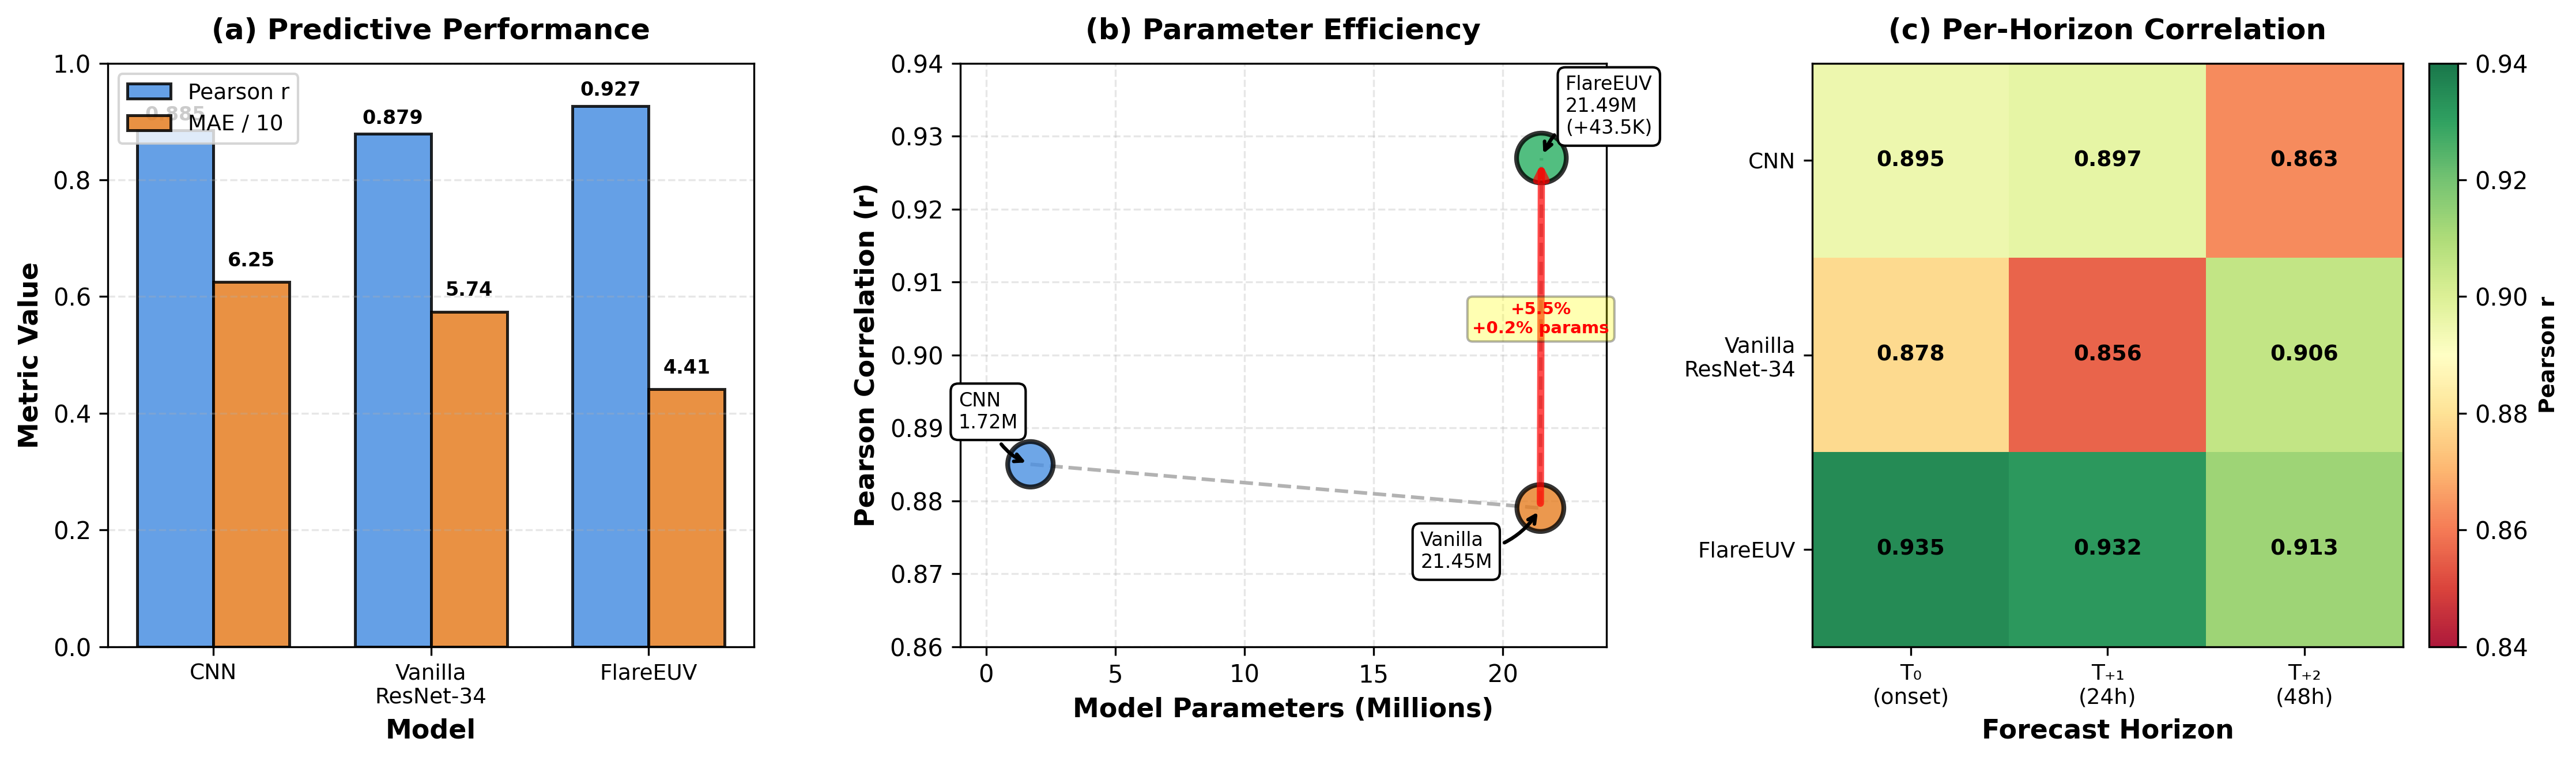

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# ============================================================
# FIGURE 1: Three-Panel Baseline Comparison (IEEE Style)
# ============================================================

# Data
models = ['Baseline CNN', 'Vanilla ResNet-34', 'FlareEUV']
models_short = ['CNN', 'Vanilla\nResNet-34', 'FlareEUV']
pearson_r = [0.885, 0.879, 0.927]
mae = [6.25, 5.74, 4.41]  # ×10⁻⁶
params_m = [1.72, 21.45, 21.49]  # Millions
r2_values = [0.716, 0.761, 0.857]

# IEEE color scheme (professional, colorblind-friendly)
colors = ['#4A90E2', '#E67E22', '#27AE60']  # Blue, Orange, Green

fig = plt.figure(figsize=(15, 4.5), dpi=300)

# ────────────────────────────────────────────────────────
# Panel (a): Performance Metrics (Pearson r + MAE)
# ────────────────────────────────────────────────────────
ax1 = plt.subplot(1, 3, 1)

x = np.arange(len(models_short))
width = 0.35

# Pearson r bars
bars1 = ax1.bar(x - width/2, pearson_r, width, label='Pearson r',
                color=colors[0], edgecolor='black', linewidth=1.2, alpha=0.85)

# MAE bars (scaled to fit nicely)
mae_scaled = [m / 10 for m in mae]  # Scale for visualization
bars2 = ax1.bar(x + width/2, mae_scaled, width, label='MAE / 10',
                color=colors[1], edgecolor='black', linewidth=1.2, alpha=0.85)

ax1.set_ylabel('Metric Value', fontsize=11, weight='bold')
ax1.set_xlabel('Model', fontsize=11, weight='bold')
ax1.set_title('(a) Predictive Performance', fontsize=12, weight='bold', pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(models_short, fontsize=9)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, 1.0)

# Add value labels
for bar, val in zip(bars1, pearson_r):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, weight='bold')

for bar, val in zip(bars2, mae):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, weight='bold')

# ────────────────────────────────────────────────────────
# Panel (b): Parameters vs Performance (Efficiency)
# ────────────────────────────────────────────────────────
ax2 = plt.subplot(1, 3, 2)

# Scatter with size proportional to R²
sizes = [r2 * 500 for r2 in r2_values]
scatter = ax2.scatter(params_m, pearson_r, s=sizes, c=colors, 
                     edgecolors='black', linewidths=2, alpha=0.8, zorder=3)

# Connect points with dashed line
ax2.plot(params_m, pearson_r, 'k--', alpha=0.3, linewidth=1.5, zorder=1)

ax2.set_xlabel('Model Parameters (Millions)', fontsize=11, weight='bold')
ax2.set_ylabel('Pearson Correlation (r)', fontsize=11, weight='bold')
ax2.set_title('(b) Parameter Efficiency', fontsize=12, weight='bold', pad=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(-1, 24)
ax2.set_ylim(0.86, 0.94)

# Annotate points
annotations = [
    ('CNN\n1.72M', (1.72, 0.885), (-30, 15)),
    ('Vanilla\n21.45M', (21.45, 0.879), (-50, -25)),
    ('FlareEUV\n21.49M\n(+43.5K)', (21.49, 0.927), (10, 10))
]

for label, (x, y), offset in annotations:
    ax2.annotate(label, xy=(x, y), xytext=offset, 
                textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                              lw=1.5))

# Highlight SE attention efficiency
ax2.annotate('', xy=(21.49, 0.927), xytext=(21.45, 0.879),
            arrowprops=dict(arrowstyle='->', lw=3, color='red', alpha=0.7))
ax2.text(21.47, 0.903, '+5.5%\n+0.2% params', 
        fontsize=7, ha='center', color='red', weight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# ────────────────────────────────────────────────────────
# Panel (c): Per-Horizon Performance Heatmap
# ────────────────────────────────────────────────────────
ax3 = plt.subplot(1, 3, 3)

# Per-horizon data
horizon_data = np.array([
    [0.895, 0.897, 0.863],  # CNN
    [0.878, 0.856, 0.906],  # Vanilla
    [0.935, 0.932, 0.913]   # FlareEUV
])

im = ax3.imshow(horizon_data, cmap='RdYlGn', aspect='auto', 
               vmin=0.84, vmax=0.94, alpha=0.9)

# Add text annotations
for i in range(len(models_short)):
    for j in range(3):
        text = ax3.text(j, i, f'{horizon_data[i, j]:.3f}',
                       ha="center", va="center", 
                       color="black", fontsize=9, weight='bold')

ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['T₀\n(onset)', 'T₊₁\n(24h)', 'T₊₂\n(48h)'], fontsize=9)
ax3.set_yticks([0, 1, 2])
ax3.set_yticklabels(models_short, fontsize=9)
ax3.set_xlabel('Forecast Horizon', fontsize=11, weight='bold')
ax3.set_title('(c) Per-Horizon Correlation', fontsize=12, weight='bold', pad=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figures/baseline_comparison_ieee.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures/baseline_comparison_ieee.png', dpi=300, bbox_inches='tight')
print("✅ Figure 1 saved: baseline_comparison_ieee.pdf")
plt.show()

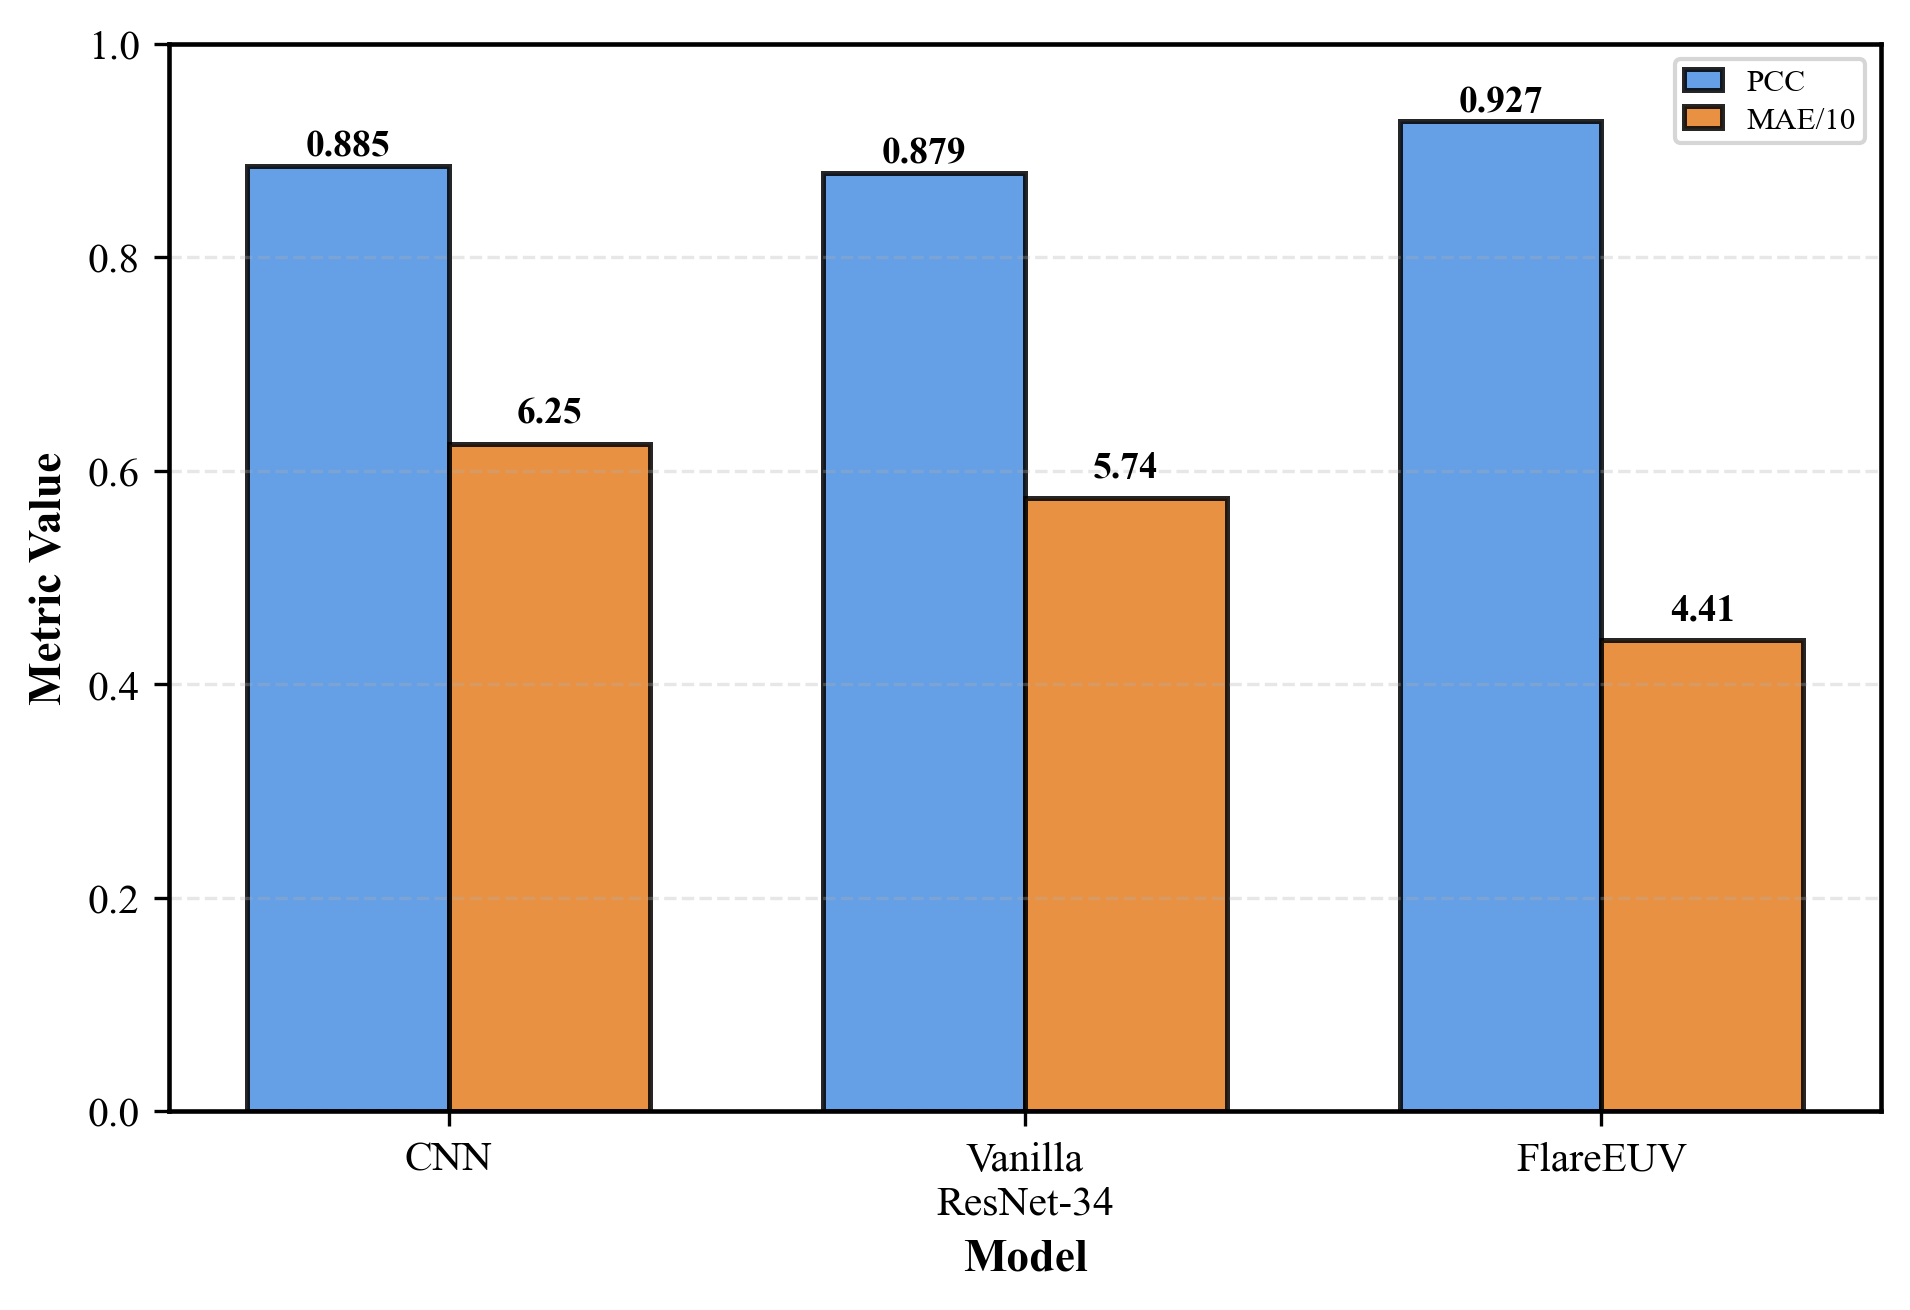

In [5]:
import matplotlib.pyplot as plt
import numpy as np

models_short = ['CNN', 'Vanilla\nResNet-34', 'FlareEUV']
pearson_r = [0.885, 0.879, 0.927]
mae = [6.25, 5.74, 4.41]  # ×10⁻⁶
colors = ['#4A90E2', '#E67E22', '#27AE60']

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

x = np.arange(len(models_short))
width = 0.35

bars1 = ax.bar(x - width/2, pearson_r, width, label='PCC',
               color=colors[0], edgecolor='black', linewidth=1.2, alpha=0.85)

mae_scaled = [m / 10 for m in mae]
bars2 = ax.bar(x + width/2, mae_scaled, width, label='MAE/10',
               color=colors[1], edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_ylabel('Metric Value', fontsize=11, weight='bold')
ax.set_xlabel('Model', fontsize=11, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_short, fontsize=10)

# ✅ Smaller, compact IEEE-style legend (no overlap)
ax.legend(fontsize=7.5, handlelength=1.2, borderpad=0.3, labelspacing=0.3)

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

for bar, val in zip(bars1, pearson_r):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, weight='bold')

for bar, val in zip(bars2, mae):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('figures/Fig7_predictive_performance.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/Fig7_predictive_performance.png', dpi=600, bbox_inches='tight')
plt.show()


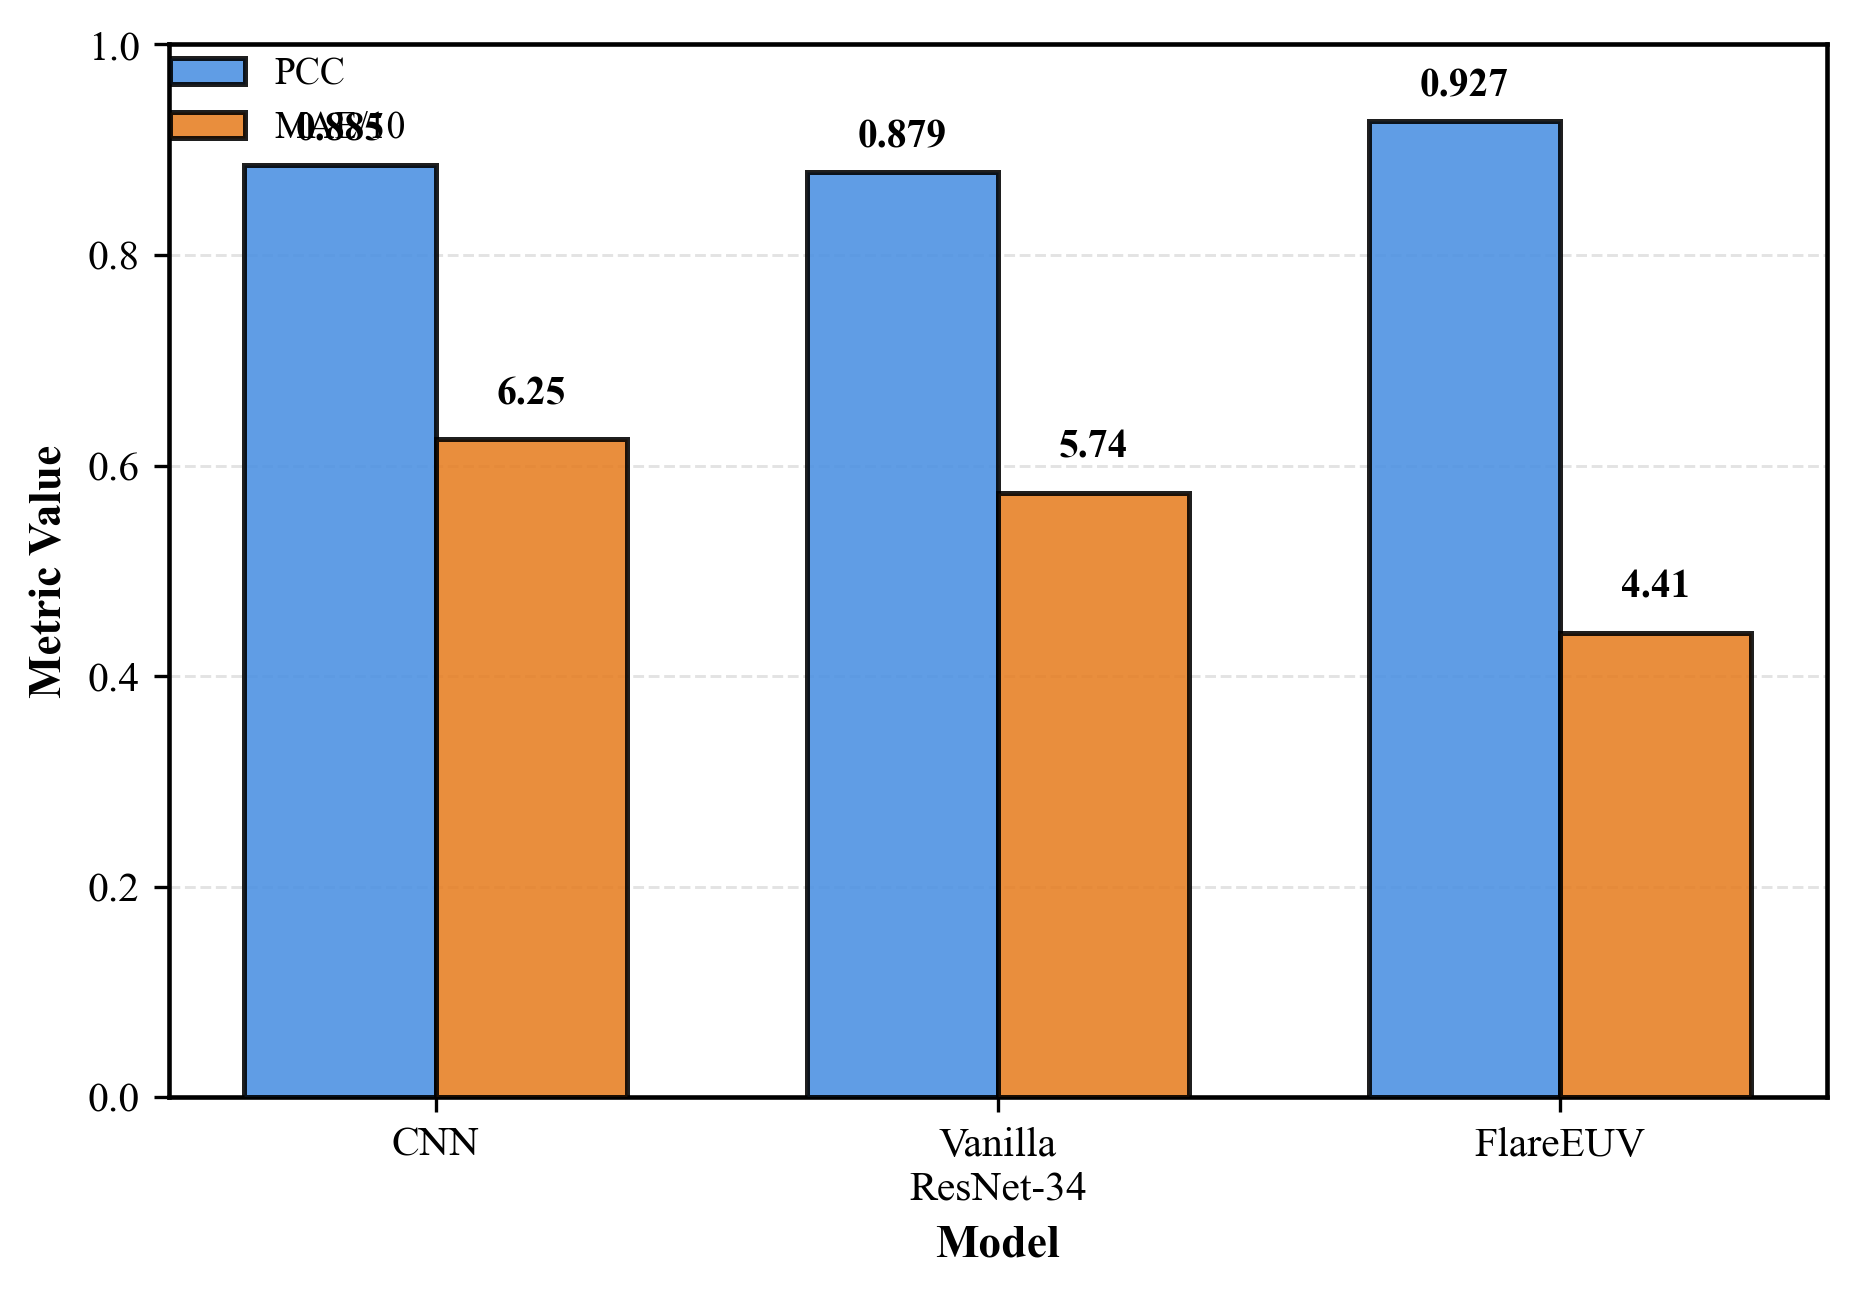

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# ============================
# IEEE FONT & STYLE
# ============================
rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.1,
})

# ============================
# DATA
# ============================
models_short = ['CNN', 'Vanilla\nResNet-34', 'FlareEUV']
pearson_r = [0.885, 0.879, 0.927]
mae = [6.25, 5.74, 4.41]  # ×10⁻⁶

# IEEE-safe colors
color_pcc = '#4A90E2'
color_mae = '#E67E22'

# ============================
# FIGURE
# ============================
fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

x = np.arange(len(models_short))
width = 0.34

# PCC bars
bars1 = ax.bar(
    x - width/2, pearson_r, width,
    label='PCC',
    color=color_pcc,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.88,
    zorder=3
)

# MAE scaled (MAE/10)
mae_scaled = [m / 10 for m in mae]
bars2 = ax.bar(
    x + width/2, mae_scaled, width,
    label='MAE/10',
    color=color_mae,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.88,
    zorder=3
)

# ============================
# AXES LABELS
# ============================
ax.set_ylabel('Metric Value', weight='bold')
ax.set_xlabel('Model', weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_short)

ax.set_ylim(0, 1.0)

# Grid (IEEE subtle)
ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.7, zorder=0)

# ============================
# VALUE ANNOTATIONS
# ============================
for bar, val in zip(bars1, pearson_r):
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.015,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9.5,
        weight='bold'
    )

for bar, val in zip(bars2, mae):
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.025,
        f'{val:.2f}',
        ha='center',
        va='bottom',
        fontsize=9.5,
        weight='bold'
    )

# ============================
# LEGEND (NO OVERLAP — IEEE STYLE)
# ============================
ax.legend(
    loc='upper left',
    bbox_to_anchor=(-0.02, 1.02),   # push legend outside bars
    frameon=False,
)

# ============================
# LAYOUT FIX (IMPORTANT)
# ============================
plt.subplots_adjust(left=0.13, right=0.98, top=0.92, bottom=0.14)

# ============================
# SAVE FIGURE (IEEE QUALITY)
# ============================
plt.savefig('figures/Fig7_predictive_performance.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/Fig7_predictive_performance.png', dpi=600, bbox_inches='tight')

plt.show()


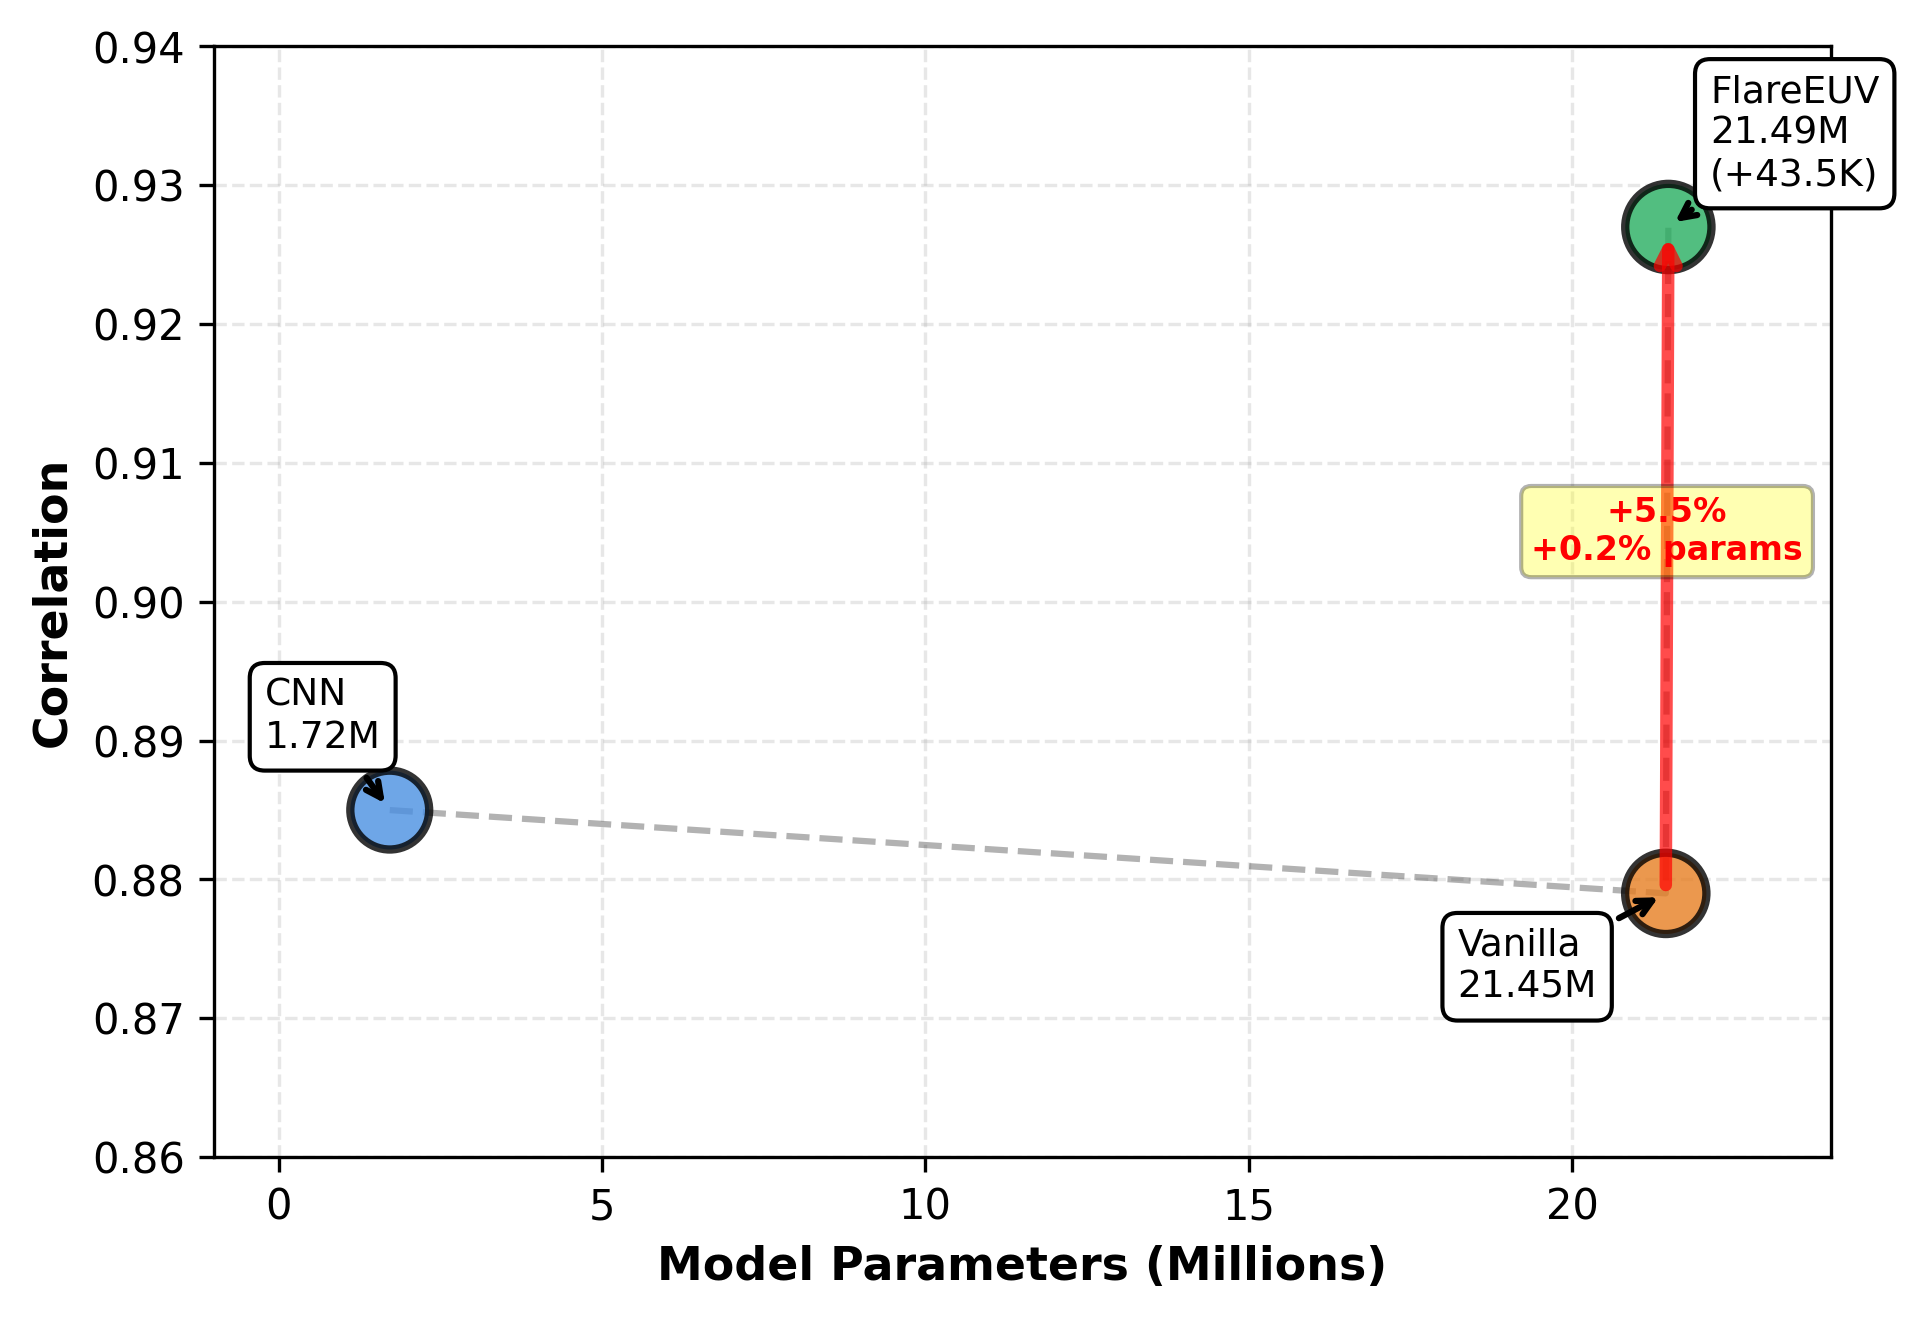

In [3]:
import matplotlib.pyplot as plt

params_m = [1.72, 21.45, 21.49]
pearson_r = [0.885, 0.879, 0.927]
r2_values = [0.716, 0.761, 0.857]
colors = ['#4A90E2', '#E67E22', '#27AE60']

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

sizes = [r2 * 500 for r2 in r2_values]
ax.scatter(params_m, pearson_r, s=sizes, c=colors,
           edgecolors='black', linewidths=2, alpha=0.8, zorder=3)

ax.plot(params_m, pearson_r, 'k--', alpha=0.3, linewidth=1.5)

ax.set_xlabel('Model Parameters (Millions)', fontsize=11, weight='bold')
ax.set_ylabel('Correlation', fontsize=11, weight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-1, 24)
ax.set_ylim(0.86, 0.94)

annotations = [
    ('CNN\n1.72M', (1.72, 0.885), (-30, 15)),
    ('Vanilla\n21.45M', (21.45, 0.879), (-50, -25)),
    ('FlareEUV\n21.49M\n(+43.5K)', (21.49, 0.927), (10, 10))
]

for label, (x, y), offset in annotations:
    ax.annotate(label, xy=(x, y), xytext=offset,
                textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', lw=1.5))

ax.annotate('', xy=(21.49, 0.927), xytext=(21.45, 0.879),
            arrowprops=dict(arrowstyle='->', lw=3, color='red', alpha=0.7))

ax.text(21.47, 0.903, '+5.5%\n+0.2% params',
        fontsize=8, ha='center', color='red', weight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('figures/Fig8_parameter_efficiency.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures/Fig8_parameter_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()


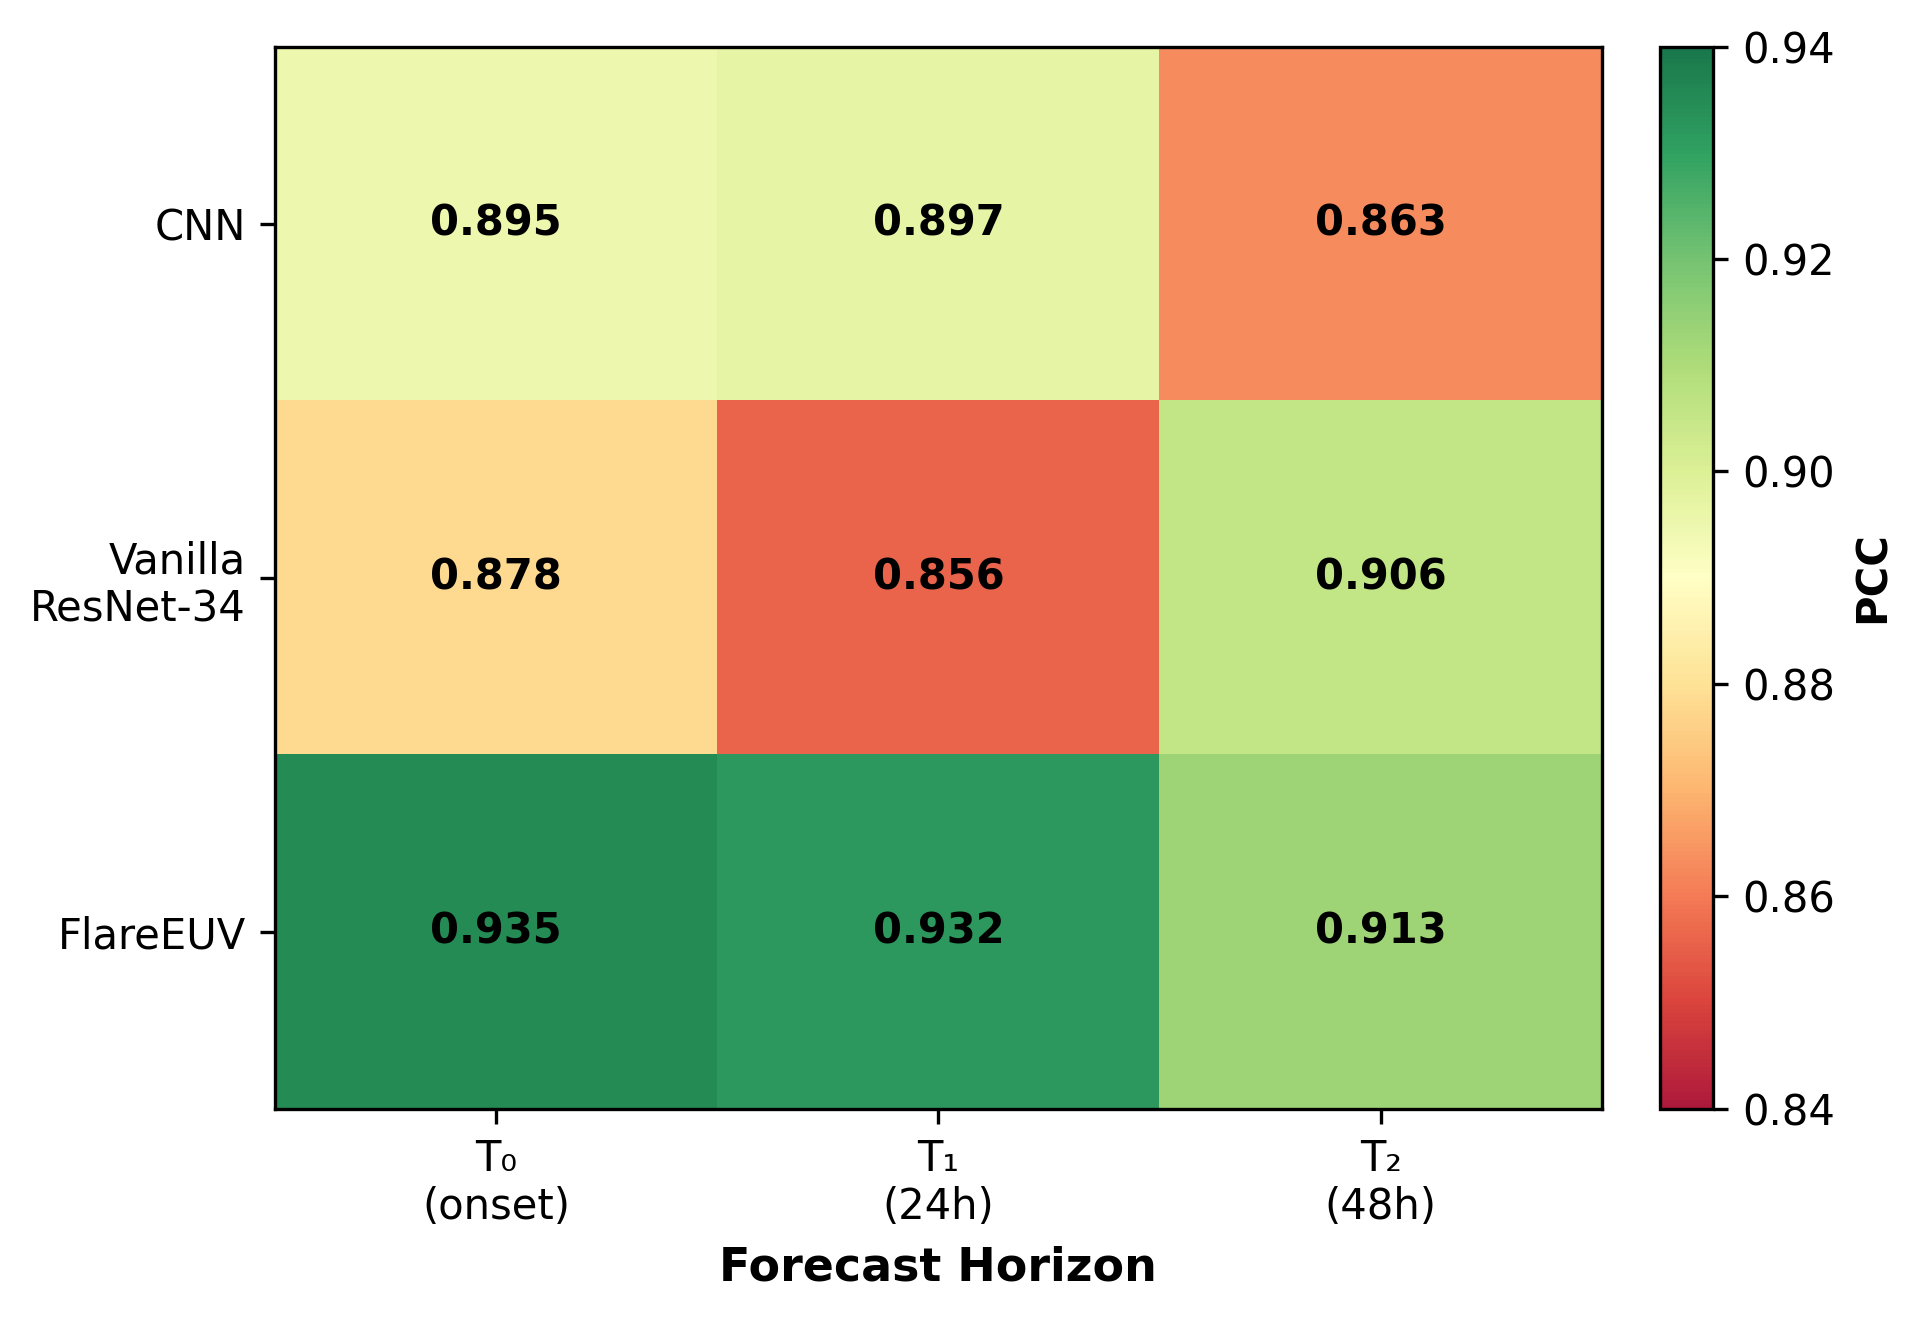

In [4]:
import matplotlib.pyplot as plt
import numpy as np

models_short = ['CNN', 'Vanilla\nResNet-34', 'FlareEUV']

horizon_data = np.array([
    [0.895, 0.897, 0.863],
    [0.878, 0.856, 0.906],
    [0.935, 0.932, 0.913]
])

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

im = ax.imshow(horizon_data, cmap='RdYlGn', aspect='auto',
               vmin=0.84, vmax=0.94, alpha=0.9)

for i in range(len(models_short)):
    for j in range(3):
        ax.text(j, i, f'{horizon_data[i, j]:.3f}',
                ha="center", va="center",
                fontsize=10, weight='bold')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['T₀\n(onset)', 'T₁\n(24h)', 'T₂\n(48h)'], fontsize=10)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(models_short, fontsize=10)

ax.set_xlabel('Forecast Horizon', fontsize=11, weight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('PCC', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('figures/Fig9_per_horizon_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures/Fig9_per_horizon_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
